## Question - 1

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import  SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split



In [3]:
df=pd.read_csv(r"C:\Users\rohit\Downloads\Titanic-Dataset.csv")

In [4]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
344,345,0,2,"Fox, Mr. Stanley Hubert",male,36.0,0,0,229236,13.0000,NaN,S
478,479,0,3,"Karlsson, Mr. Nils August",male,22.0,0,0,350060,7.5208,NaN,S
545,546,0,1,"Nicholson, Mr. Arthur Ernest",male,64.0,0,0,693,26.0000,NaN,S
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,NaN,S
124,125,0,1,"White, Mr. Percival Wayland",male,54.0,0,1,35281,77.2875,D26,S
489,490,1,3,"Coutts, Master. Eden Leslie ""Neville""",male,9.0,1,1,C.A. 37671,15.9000,NaN,S
793,794,0,1,"Hoyt, Mr. William Fisher",male,NaN,0,0,PC 17600,30.6958,NaN,C
711,712,0,1,"Klaber, Mr. Herman",male,NaN,0,0,113028,26.5500,C124,S
267,268,1,3,"Persson, Mr. Ernst Ulrik",male,25.0,1,0,347083,7.7750,NaN,S
338,339,1,3,"Dahl, Mr. Karl Edwart",male,45.0,0,0,7598,8.0500,NaN,S


In [5]:
df["Deck"] = df["Cabin"].str[0]

In [6]:
df=df.drop(["Name","Cabin","Ticket"],axis=1)

In [7]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,1,0,3,male,22.0,1,0,7.2500,S,NaN
1,2,1,1,female,38.0,1,0,71.2833,C,C
2,3,1,3,female,26.0,0,0,7.9250,S,NaN
3,4,1,1,female,35.0,1,0,53.1000,S,C
4,5,0,3,male,35.0,0,0,8.0500,S,NaN
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S,NaN
887,888,1,1,female,19.0,0,0,30.0000,S,B
888,889,0,3,female,NaN,1,2,23.4500,S,NaN
889,890,1,1,male,26.0,0,0,30.0000,C,C


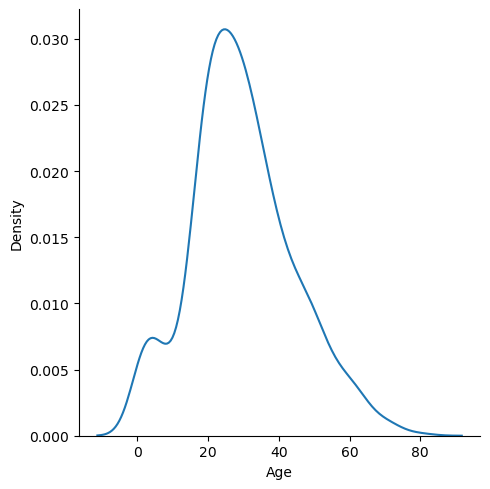

In [8]:
sns.displot(x=df["Age"],kind="kde")

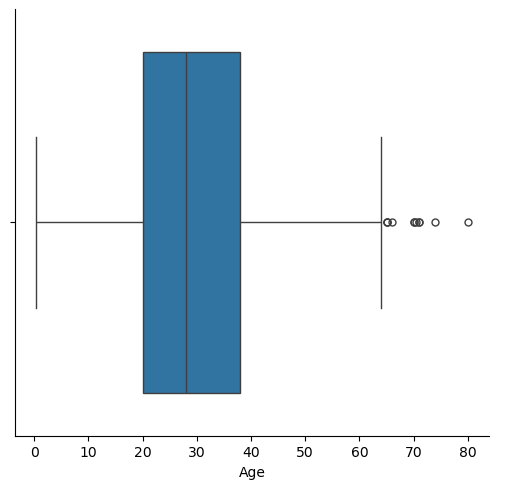

In [9]:
sns.catplot(x=df["Age"],kind="box")

In [10]:
D=df["Deck"].value_counts()
d=list(df["Deck"].unique())
d=d[1:]


In [11]:

proportions=[]
for x in d:
    p=(D.loc[x]/df.shape[0])*100  
    proportions.append(float(p))
    print(f"The percentage of {x}: ",p,"%")

The percentage of C:  6.621773288439956 %
The percentage of E:  3.5914702581369253 %
The percentage of G:  0.44893378226711567 %
The percentage of D:  3.7037037037037033 %
The percentage of A:  1.6835016835016834 %
The percentage of B:  5.274971941638609 %
The percentage of F:  1.4590347923681257 %
The percentage of T:  0.11223344556677892 %


In [12]:
c=100-sum(proportions)
proportions.append(c)
d.append("n")

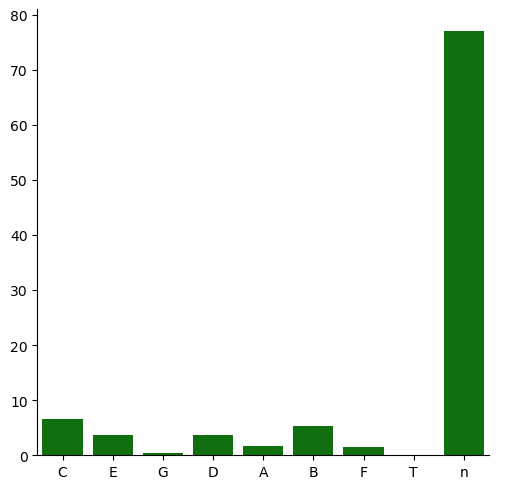

In [13]:
sns.catplot(x=d,y=proportions,kind="bar",color="green")

In [14]:
S=df["Sex"].value_counts()
s=list(df["Sex"].unique())
s

['male', 'female']

In [15]:

proportions=[]
for x in s:
    p=(S.loc[x]/df.shape[0])*100  
    proportions.append(float(p))
    print(f"The percentage of {x}: ",p,"%")

The percentage of male:  64.75869809203144 %
The percentage of female:  35.24130190796858 %


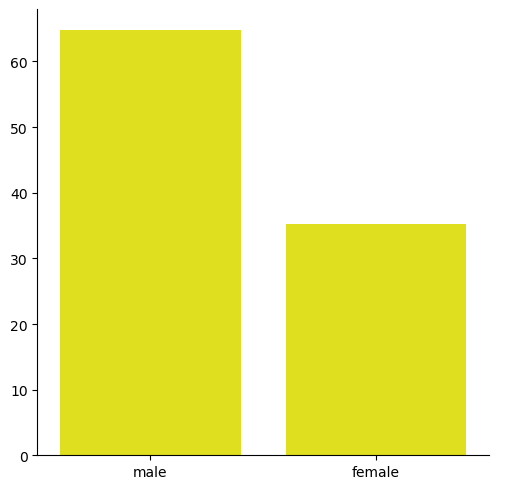

In [16]:
sns.catplot(x=s,y=proportions,kind="bar",color="yellow")

In [17]:
E=df["Embarked"].value_counts()
e=list(df["Embarked"].unique())
e.remove(np.nan)


In [18]:

proportions=[]
for x in e:
    p=(E.loc[x]/df.shape[0])*100  
    proportions.append(float(p))
    print(f"The percentage of {x}: ",p,"%")

 

The percentage of S:  72.27833894500561 %
The percentage of C:  18.855218855218855 %
The percentage of Q:  8.641975308641975 %


In [19]:
 
e.append("NAN")
proportions.append(100-sum(proportions))
print("The proportion of",e[-1],": ",proportions[-1])  

The proportion of NAN :  0.22446689113355944


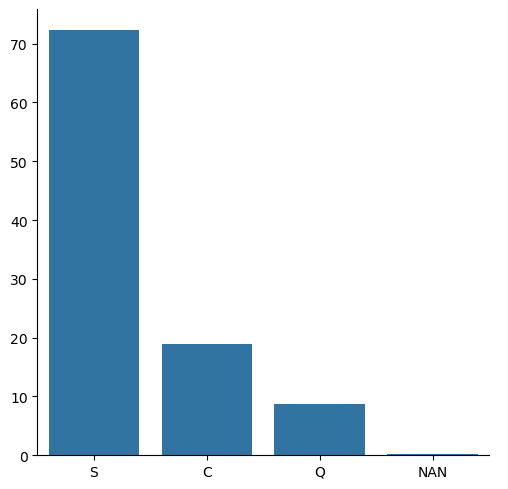

In [20]:
sns.catplot(x=e,y=proportions,kind="bar")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
 9   Deck         204 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [22]:
df.shape[0]

891

In [23]:
df.size

8910

In [24]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
Deck           687
dtype: int64

In [25]:
imputer1=SimpleImputer(missing_values=np.nan,strategy="mean",fill_value="constant")

In [26]:
imputer2=SimpleImputer(missing_values=np.nan,strategy="most_frequent",fill_value=0)

In [27]:
scaler=StandardScaler()

In [28]:
encoder=OneHotEncoder()

In [29]:
age_imputed=imputer1.fit_transform(df[["Age"]])

In [30]:
df_age_imputed=pd.DataFrame(age_imputed,columns=["Age"])

In [31]:
df_age_imputed

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [32]:
cabin_embarked_imputer=imputer2.fit_transform(df[["Deck","Embarked"]])

In [33]:
df_cabin_embarked_imputer=pd.DataFrame(cabin_embarked_imputer,columns=["Deck","Embarked"])

In [34]:
df_cabin_embarked_imputer

,Deck,Embarked
0,C,S
1,C,C
2,C,S
3,C,S
4,C,S
...,...,...
886,C,S
887,B,S
888,C,S
889,C,C


In [35]:
df_imputed=pd.concat([df_age_imputed,df_cabin_embarked_imputer],axis=1)

In [36]:
df_dropped=df.drop(["Age","Deck","Embarked"],axis=1)

In [37]:
df_transformed=pd.concat([df_dropped,df_imputed],axis=1)

In [38]:
scaler=StandardScaler()


In [39]:
df_transformed

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
0,1,0,3,male,1,0,7.2500,22.000000,C,S
1,2,1,1,female,1,0,71.2833,38.000000,C,C
2,3,1,3,female,0,0,7.9250,26.000000,C,S
3,4,1,1,female,1,0,53.1000,35.000000,C,S
4,5,0,3,male,0,0,8.0500,35.000000,C,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,0,0,13.0000,27.000000,C,S
887,888,1,1,female,0,0,30.0000,19.000000,B,S
888,889,0,3,female,1,2,23.4500,29.699118,C,S
889,890,1,1,male,0,0,30.0000,26.000000,C,C


In [40]:
df_transformed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Age            0
Deck           0
Embarked       0
dtype: int64

In [41]:
df_transformed.sample(10)

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
238,239,0,2,male,0,0,10.5000,19.000000,C,S
319,320,1,1,female,1,1,134.5000,40.000000,E,C
119,120,0,3,female,4,2,31.2750,2.000000,C,S
610,611,0,3,female,1,5,31.2750,39.000000,C,S
354,355,0,3,male,0,0,7.2250,29.699118,C,C
126,127,0,3,male,0,0,7.7500,29.699118,C,Q
278,279,0,3,male,4,1,29.1250,7.000000,C,Q
691,692,1,3,female,0,1,13.4167,4.000000,C,C
886,887,0,2,male,0,0,13.0000,27.000000,C,S
236,237,0,2,male,1,0,26.0000,44.000000,C,S


In [42]:
percentile_75=np.percentile(df_transformed["Age"].array,75,method="nearest")
percentile_25=np.percentile(df_transformed["Age"].array,25,method="nearest")
IQR=percentile_75-percentile_25
IQR
limit1=percentile_25-1.5*IQR
limit2=percentile_75+1.5*IQR

In [43]:
df_transformed.shape[0]

891

In [44]:
Q1 = np.percentile(df_transformed["Age"], 25)
Q3 = np.percentile(df_transformed["Age"], 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_transformed = df_transformed[
    (df_transformed["Age"] >= lower_bound) &
    (df_transformed["Age"] <= upper_bound)
]

In [45]:
df_transformed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Age            0
Deck           0
Embarked       0
dtype: int64

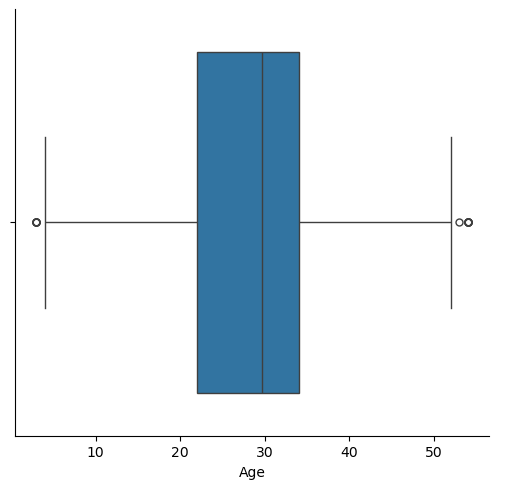

In [46]:
sns.catplot(x=df_transformed["Age"],kind="box")

In [47]:
D=df_transformed["Deck"].value_counts()
d=df_transformed["Deck"].unique()



In [48]:

proportions=[]
for x in d:
    p=(D.loc[x]/df.shape[0])*100  
    proportions.append(float(p))
    print(f"The percentage of {x}: ",p,"%")

The percentage of C:  78.56341189674522 %
The percentage of E:  3.3670033670033668 %
The percentage of G:  0.33670033670033667 %
The percentage of D:  3.254769921436588 %
The percentage of A:  1.2345679012345678 %
The percentage of B:  4.489337822671156 %
The percentage of F:  1.2345679012345678 %
The percentage of T:  0.11223344556677892 %


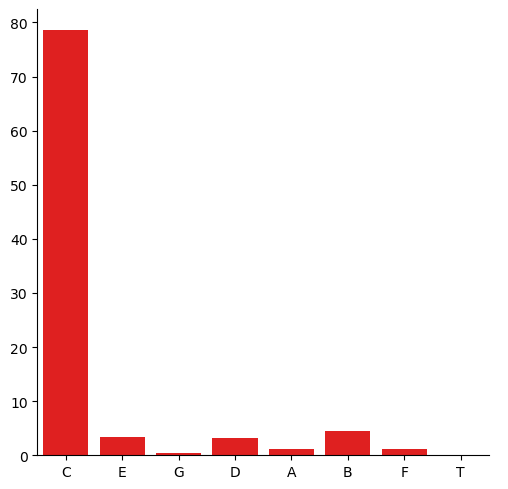

In [49]:
sns.catplot(x=d,y=proportions,kind="bar",color="red")

In [50]:
E=df_transformed["Embarked"].value_counts()
e=list(df_transformed["Embarked"].unique())


In [51]:

proportions=[]
for x in e:
    p=(E.loc[x]/df.shape[0])*100  
    proportions.append(float(p))
    print(f"The percentage of {x}: ",p,"%")

 

The percentage of S:  67.34006734006735 %
The percentage of C:  17.059483726150393 %
The percentage of Q:  8.19304152637486 %


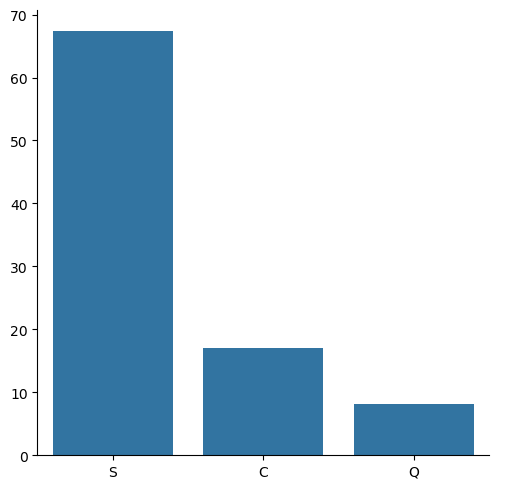

In [52]:
sns.catplot(x=e,y=proportions,kind="bar")

In [53]:
encoded_data=encoder.fit_transform(df_transformed[["Sex","Deck","Embarked"]]).toarray()
encoded_data=np.array(encoded_data,dtype="int")

In [54]:
encoded_data.ndim

2

In [55]:
c=list(encoder.get_feature_names_out())

In [56]:
df_intermediate=pd.DataFrame(encoded_data,columns=c)

In [57]:
df_intermediate

,Sex_female,Sex_male,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1,0,0,0,0,0,0,0,1
1,1,0,0,0,1,0,0,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,0,0,0,0,1
3,1,0,0,0,1,0,0,0,0,0,0,0,1
4,0,1,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,0,1,0,0,1,0,0,0,0,0,0,0,1
821,1,0,0,1,0,0,0,0,0,0,0,0,1
822,1,0,0,0,1,0,0,0,0,0,0,0,1
823,0,1,0,0,1,0,0,0,0,0,1,0,0


In [58]:
df_intermediate.isnull().sum()

Sex_female    0
Sex_male      0
Deck_A        0
Deck_B        0
Deck_C        0
Deck_D        0
Deck_E        0
Deck_F        0
Deck_G        0
Deck_T        0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [59]:
df1=df_transformed.drop(["Sex","Embarked","Deck"],axis=1)

In [60]:
df1.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
SibSp          0
Parch          0
Fare           0
Age            0
dtype: int64

In [61]:
df1 = df1.reset_index(drop=True)
df_intermediate = df_intermediate.reset_index(drop=True)

In [62]:
df_cleaned=pd.concat([df1,df_intermediate],axis=1)
df_cleaned.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
SibSp          0
Parch          0
Fare           0
Age            0
Sex_female     0
Sex_male       0
Deck_A         0
Deck_B         0
Deck_C         0
Deck_D         0
Deck_E         0
Deck_F         0
Deck_G         0
Deck_T         0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [63]:
df_cleaned.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
SibSp          0
Parch          0
Fare           0
Age            0
Sex_female     0
Sex_male       0
Deck_A         0
Deck_B         0
Deck_C         0
Deck_D         0
Deck_E         0
Deck_F         0
Deck_G         0
Deck_T         0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [64]:
y=df_cleaned[["Survived"]]
X=df_cleaned.drop("Survived",axis=1)


In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [66]:
scaler.fit(X_train[["Fare","Age"]])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [67]:
X_train[["Fare","Age"]]=scaler.transform(X_train[["Fare","Age"]])
X_test[["Fare","Age"]]=scaler.transform(X_test[["Fare","Age"]])

In [68]:
print(X_train.head())
print()
print(X_test.head())

     PassengerId  Pclass  SibSp  Parch      Fare       Age  Sex_female  \
388          420       3      0      2 -0.133315 -1.829386           1   
111          123       2      1      0 -0.011182  0.361033           0   
667          723       2      0      0 -0.363315  0.507061           0   
624          678       3      0      0 -0.428464 -1.050570           1   
748          809       2      0      0 -0.363315  0.993820           0   

     Sex_male  Deck_A  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  \
388         0       0       0       1       0       0       0       0       0   
111         1       0       0       1       0       0       0       0       0   
667         1       0       0       1       0       0       0       0       0   
624         0       0       0       1       0       0       0       0       0   
748         1       0       0       1       0       0       0       0       0   

     Embarked_C  Embarked_Q  Embarked_S  
388           0           

In [69]:
binary_model=LogisticRegression(max_iter=2000)

In [70]:
binary_model.fit(X_train,y_train)

c:\Users\rohit\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Question -2 

In [71]:
y_pred=binary_model.predict(X_test)
confusion_matrix(y_pred,y_test)

array([[91, 16],
       [11, 47]])

In [72]:
accuracy_score(y_pred,y_test)*100

83.63636363636363

In [73]:
df_cleaned.to_csv("titanic_cleaned_dataset_week2.csv")

In [77]:
df_transformed.sample(20)

df_transformed.to_csv("titanic_cleaned.csv")

In [78]:
df_transformed.sample(20)

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Age,Deck,Embarked
429,430,1,3,male,0,0,8.0500,32.000000,E,S
806,807,0,1,male,0,0,0.0000,39.000000,A,S
270,271,0,1,male,0,0,31.0000,29.699118,C,S
607,608,1,1,male,0,0,30.5000,27.000000,C,S
82,83,1,3,female,0,0,7.7875,29.699118,C,Q
300,301,1,3,female,0,0,7.7500,29.699118,C,Q
80,81,0,3,male,0,0,9.0000,22.000000,C,S
353,354,0,3,male,1,0,17.8000,25.000000,C,S
771,772,0,3,male,0,0,7.8542,48.000000,C,S
437,438,1,2,female,2,3,18.7500,24.000000,C,S
